# Board2Notes Model 2 — Kapsamlı Test ve Metrik Değerlendirme

Bu notebook, 2. modelin başarısını yalnızca tek bir `score` ile değil, görüntü iyileştirme, OCR çıktısı, yazı maskesi, yazı/arka plan kontrastı ve hız açısından ayrıntılı ölçer.

## Hesaplanan ana metrikler

### `restored` çıktısı için
- MAE/L1
- MSE/RMSE
- PSNR
- SSIM
- MS-SSIM
- Sobel edge MAE
- text-region MAE
- background MAE

### `ocr` çıktısı için
- MAE/L1
- MSE/RMSE
- PSNR
- SSIM
- MS-SSIM
- Sobel edge MAE
- text-region MAE
- background MAE
- yazı koyuluğu / arka plan beyazlığı / kontrast

### `mask_logits` çıktısı için
- IoU
- Dice/F1
- Precision
- Recall
- Accuracy
- BCE

### Çıktılar
- `per_sample_metrics.csv`
- `summary.json`
- `summary_flat.csv`
- `ALL_MODELS_SUMMARY.csv`
- En iyi / en kötü / rastgele örnek görselleri
- Histogram grafikleri
- HTML rapor


In [ ]:
# ============================================================
# 0) Ek değerlendirme paketleri
# ============================================================

!pip -q install pytorch-msssim pandas openpyxl

print("Ek değerlendirme paketleri hazır.")


Ek değerlendirme paketleri hazır.


In [ ]:
# ============================================================
# 0) Ortam + Drive + CONFIG
# ============================================================

import os, sys, json, math, time, random, zipfile, shutil, platform, gc
from pathlib import Path

import numpy as np
import cv2
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

print("Python:", platform.python_version())
print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())
assert torch.cuda.is_available(), "GPU yok. Runtime > Change runtime type > A100 GPU seç."

gpu = torch.cuda.get_device_properties(0)
print("GPU   :", gpu.name, "|", round(gpu.total_memory / 1024**3, 1), "GB")

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

HAS_BF16 = torch.cuda.is_bf16_supported()
print("bfloat16 supported:", HAS_BF16)

# ------------------------------------------------------------
# Güvenli Drive mount
# ------------------------------------------------------------
from google.colab import drive

def get_or_mount_mydrive():
    for root in [Path("/content/drive"), Path("/content/gdrive")]:
        if (root / "MyDrive").exists():
            print("Drive zaten bağlı:", root)
            return root / "MyDrive"

    m1 = Path("/content/drive")
    m1.mkdir(parents=True, exist_ok=True)
    if len(list(m1.iterdir())) == 0:
        print("Drive /content/drive altına bağlanıyor...")
        drive.mount(str(m1), force_remount=True)
        return m1 / "MyDrive"

    m2 = Path("/content/gdrive")
    m2.mkdir(parents=True, exist_ok=True)
    if len(list(m2.iterdir())) == 0:
        print("/content/drive boş değil. Drive /content/gdrive altına bağlanıyor...")
        drive.mount(str(m2), force_remount=True)
        return m2 / "MyDrive"

    raise RuntimeError("Drive mountpoint bug: Runtime > Restart session yapıp tekrar dene.")

MYDRIVE = get_or_mount_mydrive()
print("MYDRIVE:", MYDRIVE)

class CFG:
    # Paths
    PROJECT_DIR = MYDRIVE / "Board2Notes"
    DATASET_ZIP_DRIVE = PROJECT_DIR / "generated_multihead_dataset_v2.zip"
    DATASET_LOCAL = Path("/content/generated_multihead_dataset_v2")

    LOCAL_RUN_DIR = Path("/content/runs_local")
    DRIVE_RUN_DIR = PROJECT_DIR / "runs_nafnet_base_multihead"
    EXP_NAME = "nafnet_base64_multihead_v2_optimized"

    # Opsiyonel pretrained. Yoksa sıfırdan başlar.
    PRETRAINED_NAFNET = PROJECT_DIR / "best.pt"

    # NAFNet Base / width=64
    NAF_WIDTH = 64
    NAF_ENC = [2, 2, 4, 8]
    NAF_MID = 12
    NAF_DEC = [2, 2, 2, 2]

    # Data
    TRAIN_CROP_H = 512
    TRAIN_CROP_W = 512
    VAL_USE_CENTER_CROP = False  # False: 1024x576 full validation
    CACHE_IN_RAM = True

    # Auto batch
    AUTO_BATCH = True
    BATCH_CANDIDATES = [16, 12, 10, 8, 6, 4]
    BATCH_SIZE = 8
    VAL_BATCH_SIZE = 4

    PIN_MEMORY = True
    NUM_WORKERS_CACHE = 0
    NUM_WORKERS_NOCACHE = 6

    # Precision
    AMP_DTYPE = torch.bfloat16 if HAS_BF16 else torch.float16
    USE_GRAD_SCALER = (AMP_DTYPE == torch.float16)

    # torch.compile hızlandırabilir ama OOM/torch-inductor sorunlarını artırabildiği için kapalı.
    USE_TORCH_COMPILE = False
    COMPILE_MODE = "default"

    # Yazı aynalanmasın.
    USE_HFLIP = False

    # Training
    SEED = 42
    STAGE1_EPOCHS = 12
    STAGE2_EPOCHS = 8
    STAGE1_LR = 1e-4
    STAGE2_LR = 4e-5

    TEXT_WEIGHT = 2.5
    OCR_W_STAGE1 = 0.65
    MASK_W_STAGE1 = 0.50
    RESTORE_W_STAGE2 = 0.45
    OCR_W_STAGE2 = 1.25
    MASK_W_STAGE2 = 0.80

    GRAD_CLIP = 1.0
    EMA_DECAY = 0.999
    PREVIEW_EVERY = 2

    # GAN opsiyonel. Önce supervised sonucu gör; sonra gerekirse True yap.
    RUN_GAN_STAGE = False
    GAN_EPOCHS = 2
    GAN_LR_G = 2e-5
    GAN_LR_D = 1e-4
    GAN_LAMBDA = 0.005
    GAN_DISC_BASE = 32

    # Checkpoint
    SYNC_BEST_TO_DRIVE = True
    SYNC_FINAL_TO_DRIVE = True

# Dizinler
CFG.PROJECT_DIR.mkdir(parents=True, exist_ok=True)
CFG.LOCAL_RUN_DIR.mkdir(parents=True, exist_ok=True)
CFG.DRIVE_RUN_DIR.mkdir(parents=True, exist_ok=True)
(CFG.LOCAL_RUN_DIR / CFG.EXP_NAME).mkdir(parents=True, exist_ok=True)
(CFG.DRIVE_RUN_DIR / CFG.EXP_NAME).mkdir(parents=True, exist_ok=True)

# Seed
random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)
torch.cuda.manual_seed_all(CFG.SEED)

print("AMP dtype:", CFG.AMP_DTYPE, "| GradScaler:", CFG.USE_GRAD_SCALER)
print("Dataset ZIP:", CFG.DATASET_ZIP_DRIVE)
print("Local run:", CFG.LOCAL_RUN_DIR / CFG.EXP_NAME)
print("Drive run:", CFG.DRIVE_RUN_DIR / CFG.EXP_NAME)

Python: 3.12.13
Torch : 2.11.0+cu128
CUDA  : True
GPU   : NVIDIA A100-SXM4-40GB | 39.5 GB
bfloat16 supported: True
Drive /content/drive altına bağlanıyor...
Mounted at /content/drive
MYDRIVE: /content/drive/MyDrive
AMP dtype: torch.bfloat16 | GradScaler: False
Dataset ZIP: /content/drive/MyDrive/Board2Notes/generated_multihead_dataset_v2.zip
Local run: /content/runs_local/nafnet_base64_multihead_v2_optimized
Drive run: /content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_base64_multihead_v2_optimized


In [ ]:
# ============================================================
# 0.1) EVALUATION OVERRIDE
# Bu notebook eğitim yapmaz; sadece final_model.pt / GAN modeli değerlendirir.
# ============================================================

# Auto batch eğitim benchmarkını kapatıyoruz. Test için küçük/güvenli batch yeterli.
CFG.AUTO_BATCH = False
CFG.BATCH_SIZE = 4
CFG.VAL_BATCH_SIZE = 4
CFG.CACHE_IN_RAM = True
CFG.NUM_WORKERS_CACHE = 0
CFG.NUM_WORKERS_NOCACHE = 2
CFG.PREVIEW_EVERY = 999

# Kullanılacak checkpoint adayları.
# İlk bulunan model otomatik preview için yüklenir; değerlendirme bloğu tüm bulunan modelleri test eder.
EVAL_MODEL_CANDIDATES = [
    ("model2_final_user_repo", Path("/content/drive/MyDrive/B2note Proje Ek Repo/Models/YGM 4. Model B2N Nafnet/final_model.pt")),
    ("model2_final_original", CFG.DRIVE_RUN_DIR / CFG.EXP_NAME / "final_model.pt"),
    ("model2_restore_gan", CFG.DRIVE_RUN_DIR / CFG.EXP_NAME / "final_model_restore_gan.pt"),
    ("model2_restore_gan_best", CFG.DRIVE_RUN_DIR / CFG.EXP_NAME / "final_restore_gan_best.pt"),
    ("model2_stage3_gan_best", CFG.DRIVE_RUN_DIR / CFG.EXP_NAME / "final_gan_best.pt"),
]

_first_existing = None
for _name, _path in EVAL_MODEL_CANDIDATES:
    if Path(_path).exists():
        _first_existing = Path(_path)
        break

if _first_existing is not None:
    CFG.PRETRAINED_NAFNET = _first_existing
    print("İlk bulunan model otomatik yükleme için seçildi:", CFG.PRETRAINED_NAFNET)
else:
    print("UYARI: Aday model bulunamadı. Model tanımı kurulacak ama ağırlık yüklenmeyecek.")
    print("Kontrol edilen adaylar:")
    for _name, _path in EVAL_MODEL_CANDIDATES:
        print(" -", _name, ":", _path)

# Değerlendirme çıktıları
EVAL_ROOT = CFG.PROJECT_DIR / "eval_model2_multihead"
EVAL_ROOT.mkdir(parents=True, exist_ok=True)
print("Eval output root:", EVAL_ROOT)


İlk bulunan model otomatik yükleme için seçildi: /content/drive/MyDrive/B2note Proje Ek Repo/Models/YGM 4. Model B2N Nafnet/final_model.pt
Eval output root: /content/drive/MyDrive/Board2Notes/eval_model2_multihead


In [ ]:
# ============================================================
# 1) Dataset ZIP'i local diske aç + kontrol
# ============================================================

assert CFG.DATASET_ZIP_DRIVE.exists(), f"Dataset ZIP bulunamadı: {CFG.DATASET_ZIP_DRIVE}"

def find_dataset_root(base: Path):
    candidates = [base, base / "generated_multihead_dataset_v2"]
    candidates += [p for p in base.glob("*") if p.is_dir()]
    for c in candidates:
        ok = True
        for split in ["train", "val", "test"]:
            for sub in ["input", "target_restored", "target_ocr", "text_mask"]:
                if not (c / split / sub).exists():
                    ok = False
                    break
            if not ok:
                break
        if ok:
            return c
    return None

root = find_dataset_root(Path("/content"))
if root is not None:
    CFG.DATASET_LOCAL = root
    print("Dataset zaten localde:", CFG.DATASET_LOCAL)
else:
    print("Dataset ZIP local diske açılıyor...")
    with zipfile.ZipFile(CFG.DATASET_ZIP_DRIVE, "r") as z:
        z.extractall("/content")
    root = find_dataset_root(Path("/content"))
    assert root is not None, "ZIP açıldı ama dataset root bulunamadı."
    CFG.DATASET_LOCAL = root
    print("Dataset açıldı:", CFG.DATASET_LOCAL)

for split in ["train", "val", "test"]:
    print("\n", split)
    for sub in ["input", "target_restored", "target_ocr", "text_mask"]:
        p = CFG.DATASET_LOCAL / split / sub
        n = len(list(p.glob("*.png")))
        print(f"  {sub}: {n}")
        assert n > 0, f"Boş klasör: {p}"

Dataset ZIP local diske açılıyor...
Dataset açıldı: /content/generated_multihead_dataset_v2

 train
  input: 3920
  target_restored: 3920
  target_ocr: 3920
  text_mask: 3920

 val
  input: 144
  target_restored: 144
  target_ocr: 144
  text_mask: 144

 test
  input: 156
  target_restored: 156
  target_ocr: 156
  text_mask: 156


In [ ]:
# ============================================================
# 2) Dataset + DataLoader
# ============================================================

def read_rgb_uint8(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError(f"Görüntü okunamadı: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_gray_uint8(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise RuntimeError(f"Mask okunamadı: {path}")
    return img

def to_tensor_rgb(arr):
    return torch.from_numpy(np.ascontiguousarray(arr)).permute(2, 0, 1).float() / 255.0

def to_tensor_mask(arr):
    return torch.from_numpy(np.ascontiguousarray(arr)).unsqueeze(0).float() / 255.0

def resize_if_needed_4(inp, rest, ocr, mask, crop_h, crop_w):
    H, W = inp.shape[:2]
    if H >= crop_h and W >= crop_w:
        return inp, rest, ocr, mask
    scale = max(crop_h / H, crop_w / W)
    nw, nh = int(round(W * scale)), int(round(H * scale))
    inp = cv2.resize(inp, (nw, nh), interpolation=cv2.INTER_CUBIC)
    rest = cv2.resize(rest, (nw, nh), interpolation=cv2.INTER_CUBIC)
    ocr = cv2.resize(ocr, (nw, nh), interpolation=cv2.INTER_CUBIC)
    mask = cv2.resize(mask, (nw, nh), interpolation=cv2.INTER_NEAREST)
    return inp, rest, ocr, mask

def random_crop_4(inp, rest, ocr, mask, crop_h, crop_w):
    inp, rest, ocr, mask = resize_if_needed_4(inp, rest, ocr, mask, crop_h, crop_w)
    H, W = inp.shape[:2]
    y = np.random.randint(0, H - crop_h + 1)
    x = np.random.randint(0, W - crop_w + 1)
    return (
        inp[y:y+crop_h, x:x+crop_w],
        rest[y:y+crop_h, x:x+crop_w],
        ocr[y:y+crop_h, x:x+crop_w],
        mask[y:y+crop_h, x:x+crop_w],
    )

def center_crop_4(inp, rest, ocr, mask, crop_h, crop_w):
    inp, rest, ocr, mask = resize_if_needed_4(inp, rest, ocr, mask, crop_h, crop_w)
    H, W = inp.shape[:2]
    y = max(0, (H - crop_h) // 2)
    x = max(0, (W - crop_w) // 2)
    return (
        inp[y:y+crop_h, x:x+crop_w],
        rest[y:y+crop_h, x:x+crop_w],
        ocr[y:y+crop_h, x:x+crop_w],
        mask[y:y+crop_h, x:x+crop_w],
    )

class MultiHeadBoardDataset(Dataset):
    def __init__(self, root, split, train=True, cache=True):
        self.root = Path(root)
        self.split = split
        self.train = train
        self.cache = cache

        self.in_dir = self.root / split / "input"
        self.rest_dir = self.root / split / "target_restored"
        self.ocr_dir = self.root / split / "target_ocr"
        self.mask_dir = self.root / split / "text_mask"

        self.files = sorted([p.name for p in self.in_dir.glob("*.png")])
        assert self.files, f"Dosya yok: {self.in_dir}"

        self.mem = None
        if cache:
            print(f"[{split}] RAM cache başlıyor: {len(self.files)} örnek")
            self.mem = []
            for f in tqdm(self.files, desc=f"cache {split}"):
                self.mem.append(self._load_np(f))
            mb = sum(a.nbytes + b.nbytes + c.nbytes + d.nbytes for a, b, c, d in self.mem) / 1024**2
            print(f"[{split}] RAM cache hazır: {mb:.1f} MB")

    def _load_np(self, f):
        return (
            read_rgb_uint8(self.in_dir / f),
            read_rgb_uint8(self.rest_dir / f),
            read_rgb_uint8(self.ocr_dir / f),
            read_gray_uint8(self.mask_dir / f),
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        f = self.files[idx]
        if self.cache:
            inp, rest, ocr, mask = self.mem[idx]
        else:
            inp, rest, ocr, mask = self._load_np(f)

        if self.train:
            inp, rest, ocr, mask = random_crop_4(inp, rest, ocr, mask, CFG.TRAIN_CROP_H, CFG.TRAIN_CROP_W)

            if CFG.USE_HFLIP and random.random() < 0.5:
                inp = inp[:, ::-1].copy()
                rest = rest[:, ::-1].copy()
                ocr = ocr[:, ::-1].copy()
                mask = mask[:, ::-1].copy()
        elif CFG.VAL_USE_CENTER_CROP:
            inp, rest, ocr, mask = center_crop_4(inp, rest, ocr, mask, CFG.TRAIN_CROP_H, CFG.TRAIN_CROP_W)

        return {
            "input": to_tensor_rgb(inp),
            "target_restored": to_tensor_rgb(rest),
            "target_ocr": to_tensor_rgb(ocr),
            "text_mask": to_tensor_mask(mask),
            "file": f,
        }

def make_loaders(batch_size, val_batch_size):
    workers = CFG.NUM_WORKERS_CACHE if CFG.CACHE_IN_RAM else CFG.NUM_WORKERS_NOCACHE
    persistent = workers > 0

    train_ds = MultiHeadBoardDataset(CFG.DATASET_LOCAL, "train", True, CFG.CACHE_IN_RAM)
    val_ds = MultiHeadBoardDataset(CFG.DATASET_LOCAL, "val", False, CFG.CACHE_IN_RAM)
    test_ds = MultiHeadBoardDataset(CFG.DATASET_LOCAL, "test", False, CFG.CACHE_IN_RAM)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=workers,
        pin_memory=CFG.PIN_MEMORY,
        persistent_workers=persistent,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=workers,
        pin_memory=CFG.PIN_MEMORY,
        persistent_workers=persistent,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=workers,
        pin_memory=CFG.PIN_MEMORY,
        persistent_workers=persistent,
    )
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

print("Dataset/DataLoader sınıfları hazır.")

Dataset/DataLoader sınıfları hazır.


In [ ]:
# ============================================================
# 3) NAFNet-Base Multi-Head Model + safe load
# ============================================================

class LayerNorm2d(nn.Module):
    def __init__(self, c, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(c))
        self.bias = nn.Parameter(torch.zeros(c))
        self.eps = eps

    def forward(self, x):
        u = x.mean(1, keepdim=True)
        s = (x - u).pow(2).mean(1, keepdim=True)
        x = (x - u) / torch.sqrt(s + self.eps)
        return x * self.weight[None, :, None, None] + self.bias[None, :, None, None]

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c, dw_expand=2, ffn_expand=2):
        super().__init__()
        dw = c * dw_expand
        self.conv1 = nn.Conv2d(c, dw, 1)
        self.conv2 = nn.Conv2d(dw, dw, 3, 1, 1, groups=dw)
        self.conv3 = nn.Conv2d(dw // 2, c, 1)
        self.sca = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(dw // 2, dw // 2, 1))
        self.sg = SimpleGate()

        ffn = c * ffn_expand
        self.conv4 = nn.Conv2d(c, ffn, 1)
        self.conv5 = nn.Conv2d(ffn // 2, c, 1)

        self.norm1 = LayerNorm2d(c)
        self.norm2 = LayerNorm2d(c)
        self.beta = nn.Parameter(torch.zeros((1, c, 1, 1)))
        self.gamma = nn.Parameter(torch.zeros((1, c, 1, 1)))

    def forward(self, inp):
        x = self.norm1(inp)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.sg(x)
        x = x * self.sca(x)
        x = self.conv3(x)
        y = inp + x * self.beta

        x = self.norm2(y)
        x = self.conv4(x)
        x = self.sg(x)
        x = self.conv5(x)
        return y + x * self.gamma

class NAFNetMultiHead(nn.Module):
    def __init__(self, img_channel=3, width=64, middle_blk_num=12,
                 enc_blk_nums=(2, 2, 4, 8), dec_blk_nums=(2, 2, 2, 2)):
        super().__init__()
        self.intro = nn.Conv2d(img_channel, width, 3, 1, 1)

        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()

        chan = width
        for n in enc_blk_nums:
            self.encoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
            self.downs.append(nn.Conv2d(chan, 2 * chan, 2, 2))
            chan *= 2

        self.middle_blks = nn.Sequential(*[NAFBlock(chan) for _ in range(middle_blk_num)])

        for n in dec_blk_nums:
            self.ups.append(nn.Sequential(nn.Conv2d(chan, chan * 2, 1, bias=False), nn.PixelShuffle(2)))
            chan //= 2
            self.decoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))

        self.ending_restored = nn.Conv2d(width, 3, 3, 1, 1)
        self.ending_ocr = nn.Conv2d(width, 3, 3, 1, 1)
        self.mask_head = nn.Sequential(
            nn.Conv2d(width, width // 2, 3, 1, 1),
            nn.GELU(),
            nn.Conv2d(width // 2, 1, 3, 1, 1),
        )
        self.padder_size = 2 ** len(self.encoders)

    def check_image_size(self, x):
        _, _, h, w = x.size()
        ph = (self.padder_size - h % self.padder_size) % self.padder_size
        pw = (self.padder_size - w % self.padder_size) % self.padder_size
        return F.pad(x, (0, pw, 0, ph))

    def forward_features(self, inp):
        _, _, H, W = inp.shape
        x_in = self.check_image_size(inp)
        x = self.intro(x_in)

        skips = []
        for enc, down in zip(self.encoders, self.downs):
            x = enc(x)
            skips.append(x)
            x = down(x)

        x = self.middle_blks(x)

        for dec, up, skip in zip(self.decoders, self.ups, skips[::-1]):
            x = up(x)
            x = x + skip
            x = dec(x)

        return x, x_in, H, W

    def forward(self, inp):
        feat, x_in, H, W = self.forward_features(inp)
        return {
            "restored": (self.ending_restored(feat) + x_in)[:, :, :H, :W],
            "ocr": (self.ending_ocr(feat) + x_in)[:, :, :H, :W],
            "mask_logits": self.mask_head(feat)[:, :, :H, :W],
        }

def build_model():
    return NAFNetMultiHead(3, CFG.NAF_WIDTH, CFG.NAF_MID, CFG.NAF_ENC, CFG.NAF_DEC)

def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def strip_prefix(k):
    for pre in ["module.", "model.", "net.", "netG.", "_orig_mod."]:
        if k.startswith(pre):
            return k[len(pre):]
    return k

def extract_state(ck):
    if isinstance(ck, dict):
        for key in ["params_ema", "params", "state_dict", "model", "net", "weights", "ema"]:
            if key in ck and isinstance(ck[key], dict):
                return ck[key]
    return ck

def load_pretrained_flexible(model, path):
    path = Path(path)
    if not path.exists():
        print("Pretrained yok, sıfırdan başlanacak:", path)
        return

    print("Pretrained yükleniyor:", path)
    ck = safe_torch_load(path, map_location="cpu")
    raw = extract_state(ck)
    sd = {strip_prefix(k): v for k, v in raw.items()}
    msd = model.state_dict()

    loadable = {}
    for k, v in sd.items():
        if k in msd and tuple(msd[k].shape) == tuple(v.shape):
            loadable[k] = v

    # Eski single-head ending -> restored + ocr
    if "ending.weight" in sd and "ending.bias" in sd:
        if "ending_restored.weight" in msd and tuple(msd["ending_restored.weight"].shape) == tuple(sd["ending.weight"].shape):
            loadable["ending_restored.weight"] = sd["ending.weight"]
            loadable["ending_restored.bias"] = sd["ending.bias"]
            loadable["ending_ocr.weight"] = sd["ending.weight"].clone()
            loadable["ending_ocr.bias"] = sd["ending.bias"].clone()
            print("Single-head ending -> restored/ocr headlerine kopyalandı.")

    res = model.load_state_dict(loadable, strict=False)
    print("Yüklenen tensor:", len(loadable), "| Eksik:", len(res.missing_keys), "| Fazla:", len(res.unexpected_keys))

def orig_model(model):
    return model._orig_mod if hasattr(model, "_orig_mod") else model

model = build_model().cuda()
print("Parametre:", round(sum(p.numel() for p in model.parameters()) / 1e6, 2), "M")

load_pretrained_flexible(model, CFG.PRETRAINED_NAFNET)

if CFG.USE_TORCH_COMPILE:
    try:
        model = torch.compile(model, mode=CFG.COMPILE_MODE)
        print("torch.compile uygulandı:", CFG.COMPILE_MODE)
    except Exception as e:
        print("torch.compile başarısız, compile olmadan devam:", repr(e))
        CFG.USE_TORCH_COMPILE = False

print("Model hazır.")

Parametre: 116.0 M
Pretrained yükleniyor: /content/drive/MyDrive/B2note Proje Ek Repo/Models/YGM 4. Model B2N Nafnet/final_model.pt
Yüklenen tensor: 670 | Eksik: 0 | Fazla: 0
Model hazır.


[train] RAM cache başlıyor: 3920 örnek


cache train:   0%|          | 0/3920 [00:00<?, ?it/s]

[train] RAM cache hazır: 22050.0 MB
[val] RAM cache başlıyor: 144 örnek


cache val:   0%|          | 0/144 [00:00<?, ?it/s]

[val] RAM cache hazır: 810.0 MB
[test] RAM cache başlıyor: 156 örnek


cache test:   0%|          | 0/156 [00:00<?, ?it/s]

[test] RAM cache hazır: 877.5 MB


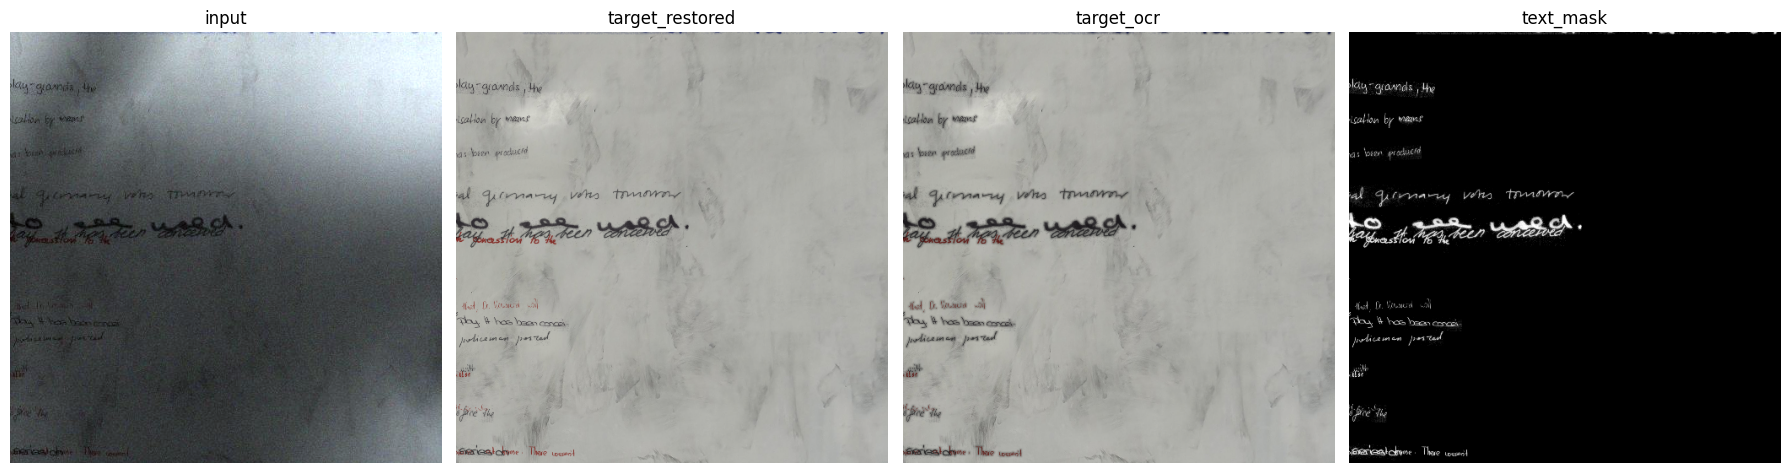

Final BATCH_SIZE: 4 | VAL_BATCH_SIZE: 4


In [ ]:
# ============================================================
# 4) Loss / Metrics / EMA / Auto Batch / Loaders
# ============================================================

def amp_ctx():
    return autocast("cuda", dtype=CFG.AMP_DTYPE)

def psnr(pred, target):
    pred = pred.float().clamp(0, 1)
    target = target.float().clamp(0, 1)
    mse = F.mse_loss(pred, target)
    return (-10 * torch.log10(mse + 1e-10)).item()

def mask_iou(logits, target, th=0.5):
    pred = (torch.sigmoid(logits.float()) > th).float()
    target = (target.float() > 0.5).float()
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = ((pred + target) > 0).float().sum(dim=(1, 2, 3))
    return ((inter + 1) / (union + 1)).mean().item()

def gaussian_window(ws=11, sigma=1.5, channels=3):
    coords = torch.arange(ws).float() - ws // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    w = (g[:, None] @ g[None, :]).expand(channels, 1, ws, ws).contiguous()
    return w

class SSIMLoss(nn.Module):
    def __init__(self, ws=11, sigma=1.5, channels=3):
        super().__init__()
        self.ws = ws
        self.channels = channels
        self.register_buffer("win", gaussian_window(ws, sigma, channels))

    def forward(self, x, y):
        x = x.float().clamp(0, 1)
        y = y.float().clamp(0, 1)
        p = self.ws // 2
        win = self.win.to(device=x.device, dtype=torch.float32)

        mx = F.conv2d(x, win, padding=p, groups=self.channels)
        my = F.conv2d(y, win, padding=p, groups=self.channels)
        mx2, my2, mxy = mx * mx, my * my, mx * my
        vx = F.conv2d(x * x, win, padding=p, groups=self.channels) - mx2
        vy = F.conv2d(y * y, win, padding=p, groups=self.channels) - my2
        vxy = F.conv2d(x * y, win, padding=p, groups=self.channels) - mxy

        C1 = 0.01 ** 2
        C2 = 0.03 ** 2
        ssim = ((2 * mxy + C1) * (2 * vxy + C2)) / ((mx2 + my2 + C1) * (vx + vy + C2) + 1e-8)
        return 1 - ssim.mean()

class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
        self.register_buffer("kx", kx.view(1,1,3,3))
        self.register_buffer("ky", kx.t().contiguous().view(1,1,3,3))

    def grad(self, x):
        x = x.float().clamp(0, 1)
        g = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        gx = F.conv2d(g, self.kx.to(x.device), padding=1)
        gy = F.conv2d(g, self.ky.to(x.device), padding=1)
        return torch.sqrt(gx * gx + gy * gy + 1e-6)

    def forward(self, x, y):
        return F.l1_loss(self.grad(x), self.grad(y))

class DiceLoss(nn.Module):
    def forward(self, logits, target):
        prob = torch.sigmoid(logits.float())
        target = target.float()
        inter = (prob * target).sum(dim=(1,2,3))
        union = prob.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
        return 1 - ((2 * inter + 1) / (union + 1)).mean()

class MultiHeadLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ssim = SSIMLoss()
        self.edge = EdgeLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def img_loss(self, p, t, edge_w=0.1, ssim_w=0.2):
        p = p.float()
        t = t.float()
        return F.l1_loss(p, t) + ssim_w * self.ssim(p, t) + edge_w * self.edge(p, t)

    def ocr_loss(self, p, t, m, text_w=2.5, edge_w=0.2, ssim_w=0.2):
        p = p.float()
        t = t.float()
        m = m.float()
        w = 1 + (text_w - 1) * m
        tw = (w * (p - t).abs()).mean()
        return tw + ssim_w * self.ssim(p, t) + edge_w * self.edge(p, t)

    def mask_loss(self, logits, target):
        return self.bce(logits.float(), target.float()) + self.dice(logits, target)

    def forward(self, out, batch, stage="stage1"):
        rest_l = self.img_loss(
            out["restored"], batch["target_restored"],
            edge_w=0.10 if stage == "stage1" else 0.08,
            ssim_w=0.20 if stage == "stage1" else 0.15,
        )
        ocr_l = self.ocr_loss(
            out["ocr"], batch["target_ocr"], batch["text_mask"],
            text_w=CFG.TEXT_WEIGHT,
            edge_w=0.16 if stage == "stage1" else 0.25,
            ssim_w=0.15 if stage == "stage1" else 0.20,
        )
        mask_l = self.mask_loss(out["mask_logits"], batch["text_mask"])

        if stage == "stage1":
            total = rest_l + CFG.OCR_W_STAGE1 * ocr_l + CFG.MASK_W_STAGE1 * mask_l
        else:
            total = CFG.RESTORE_W_STAGE2 * rest_l + CFG.OCR_W_STAGE2 * ocr_l + CFG.MASK_W_STAGE2 * mask_l

        return total, {"restore": rest_l.detach(), "ocr": ocr_l.detach(), "mask": mask_l.detach()}

loss_fn = MultiHeadLoss().cuda()

class EMA:
    @staticmethod
    def strip(k):
        return k.replace("_orig_mod.", "", 1) if k.startswith("_orig_mod.") else k

    def __init__(self, model, decay):
        self.decay = decay
        self.shadow = {self.strip(k): v.detach().clone() for k, v in orig_model(model).state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in orig_model(model).state_dict().items():
            sk = self.strip(k)
            if v.dtype.is_floating_point:
                self.shadow[sk].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
            else:
                self.shadow[sk] = v.detach().clone()

def batch_to_device(b):
    out = {}
    for k, v in b.items():
        if torch.is_tensor(v):
            out[k] = v.cuda(non_blocking=True)
        else:
            out[k] = v
    return out

@torch.no_grad()
def validate(model_eval, loader, desc="val"):
    model_eval.eval()
    totals = {"rest_l1":0, "ocr_l1":0, "psnr_rest":0, "psnr_ocr":0, "mask_iou":0, "n":0}

    for b in tqdm(loader, desc=desc, leave=False):
        b = batch_to_device(b)
        bs = b["input"].size(0)

        with amp_ctx():
            o = model_eval(b["input"])
            rest = o["restored"].clamp(0, 1)
            ocr = o["ocr"].clamp(0, 1)

        totals["rest_l1"] += F.l1_loss(rest.float(), b["target_restored"].float()).item() * bs
        totals["ocr_l1"] += F.l1_loss(ocr.float(), b["target_ocr"].float()).item() * bs
        totals["psnr_rest"] += psnr(rest, b["target_restored"]) * bs
        totals["psnr_ocr"] += psnr(ocr, b["target_ocr"]) * bs
        totals["mask_iou"] += mask_iou(o["mask_logits"], b["text_mask"]) * bs
        totals["n"] += bs

    n = max(1, totals["n"])
    m = {k: v / n for k, v in totals.items() if k != "n"}
    m["score"] = m["rest_l1"] + m["ocr_l1"] + 0.20 * (1 - m["mask_iou"])
    return m

def state_dict_clean(model):
    return {k.replace("_orig_mod.", "", 1): v for k, v in orig_model(model).state_dict().items()}

def save_ckpt(path, model, ema, epoch, stage, metrics, opt=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "stage": stage,
        "epoch": epoch,
        "metrics": metrics,
        "model": state_dict_clean(model),
        "ema": ema.shadow if ema is not None else None,
        "cfg": {"width": CFG.NAF_WIDTH, "enc": CFG.NAF_ENC, "mid": CFG.NAF_MID, "dec": CFG.NAF_DEC},
        "optimizer": opt.state_dict() if opt is not None else None,
    }
    torch.save(payload, path)

def sync_to_drive(local_path, drive_path):
    local_path = Path(local_path)
    drive_path = Path(drive_path)
    try:
        drive_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(local_path, drive_path)
    except Exception as e:
        print("Drive sync hatası, devam ediliyor:", repr(e))

@torch.no_grad()
def save_preview(model_eval, ds, path, n=4):
    model_eval.eval()
    n = min(n, len(ds))
    fig, ax = plt.subplots(n, 6, figsize=(22, 4*n))
    ax = np.atleast_2d(ax)

    for i in range(n):
        item = ds[i * max(1, len(ds) // n)]
        inp = item["input"].unsqueeze(0).cuda(non_blocking=True)
        with amp_ctx():
            out = model_eval(inp)

        rest = out["restored"].clamp(0,1)[0].float().cpu()
        ocr = out["ocr"].clamp(0,1)[0].float().cpu()
        pm = torch.sigmoid(out["mask_logits"])[0,0].float().cpu()

        cols = [
            ("input", item["input"].permute(1,2,0)),
            ("pred_rest", rest.permute(1,2,0)),
            ("target_rest", item["target_restored"].permute(1,2,0)),
            ("pred_ocr", ocr.permute(1,2,0)),
            ("target_ocr", item["target_ocr"].permute(1,2,0)),
            ("pred_mask", pm),
        ]
        for j, (title, img) in enumerate(cols):
            ax[i, j].imshow(img.numpy(), cmap="gray" if "mask" in title else None)
            ax[i, j].set_title(title)
            ax[i, j].axis("off")

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=100)
    plt.close("all")

def auto_select_batch(model):
    if not CFG.AUTO_BATCH:
        return CFG.BATCH_SIZE

    print("Auto batch seçimi başlıyor...")
    model.train()

    for bs in CFG.BATCH_CANDIDATES:
        x = None
        batch = None
        out = None
        loss = None
        try:
            torch.cuda.empty_cache()
            model.zero_grad(set_to_none=True)

            x = torch.randn(bs, 3, CFG.TRAIN_CROP_H, CFG.TRAIN_CROP_W, device="cuda")
            batch = {
                "input": x,
                "target_restored": torch.rand_like(x),
                "target_ocr": torch.rand_like(x),
                "text_mask": torch.rand(bs, 1, CFG.TRAIN_CROP_H, CFG.TRAIN_CROP_W, device="cuda"),
            }

            with amp_ctx():
                out = model(batch["input"])
                loss, _ = loss_fn(out, batch, "stage1")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            model.zero_grad(set_to_none=True)

            del x, batch, out, loss
            gc.collect()
            torch.cuda.empty_cache()

            print("Seçilen BATCH_SIZE:", bs)
            return bs

        except torch.cuda.OutOfMemoryError:
            print("OOM batch:", bs)
            model.zero_grad(set_to_none=True)
            del x, batch, out, loss
            gc.collect()
            torch.cuda.empty_cache()

    print("Tüm adaylar OOM verdi, batch=4 seçildi.")
    return 4

# Batch seç + loader kur
CFG.BATCH_SIZE = auto_select_batch(model)
CFG.VAL_BATCH_SIZE = min(4, CFG.BATCH_SIZE)

train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(CFG.BATCH_SIZE, CFG.VAL_BATCH_SIZE)

# Preview
s = train_ds[0]
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
for i, (k, img) in enumerate([
    ("input", s["input"].permute(1,2,0)),
    ("target_restored", s["target_restored"].permute(1,2,0)),
    ("target_ocr", s["target_ocr"].permute(1,2,0)),
    ("text_mask", s["text_mask"][0]),
]):
    ax[i].imshow(img.numpy(), cmap="gray" if k == "text_mask" else None)
    ax[i].set_title(k)
    ax[i].axis("off")
plt.tight_layout()
plt.show()
plt.close("all")

print("Final BATCH_SIZE:", CFG.BATCH_SIZE, "| VAL_BATCH_SIZE:", CFG.VAL_BATCH_SIZE)

In [ ]:
# ============================================================
# Kritik import düzeltmesi
# ============================================================

import re
import json
import math
import gc
import time
import shutil
from pathlib import Path
from PIL import Image

print("Kritik importlar hazır.")

Kritik importlar hazır.


In [ ]:
# ============================================================
# 6) PROFESYONEL MODEL 2 TEST / METRİK DEĞERLENDİRME
# ============================================================

import csv
import pandas as pd
from datetime import datetime
from pytorch_msssim import ssim as torch_ssim
try:
    from pytorch_msssim import ms_ssim as torch_ms_ssim
except Exception:
    torch_ms_ssim = None

# ------------------------------------------------------------
# Ayarlar
# ------------------------------------------------------------

EVAL_SPLITS = ["test", "val"]  # istersen ["test"] yap
MAX_EVAL_SAMPLES = None        # hızlı test için örn. 40 yap; tam ölçüm için None
SAVE_TOP_K = 12
SAVE_RANDOM_K = 12
MASK_THRESHOLD = 0.50
RUN_TROCR_PROXY = False        # Çok yavaş olabilir. İstersen True yap.
TROCR_MODEL_NAME = "microsoft/trocr-large-handwritten"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
EVAL_RUN_DIR = EVAL_ROOT / f"eval_run_{timestamp}"
EVAL_RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Eval run dir:", EVAL_RUN_DIR)

# ------------------------------------------------------------
# Model yükleme
# ------------------------------------------------------------

def clean_name(name: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_\-]+", "_", str(name)).strip("_")

def load_model_for_eval(ckpt_path: Path):
    ckpt_path = Path(ckpt_path)
    assert ckpt_path.exists(), f"Checkpoint bulunamadı: {ckpt_path}"

    m = build_model().cuda().eval()
    ck = safe_torch_load(ckpt_path, map_location="cpu")

    state = None
    if isinstance(ck, dict):
        for key in ["ema", "model", "state_dict", "student_model"]:
            if key in ck and isinstance(ck[key], dict):
                state = ck[key]
                print(f"  state key: {key}")
                break
        if state is None and all(torch.is_tensor(v) for v in ck.values()):
            state = ck
    else:
        state = ck

    assert isinstance(state, dict), f"State dict çıkarılamadı: {ckpt_path}"

    # Prefix temizliği
    state = {strip_prefix(str(k)): v for k, v in state.items()}
    res = m.load_state_dict(state, strict=False)

    print("  missing:", len(res.missing_keys), "| unexpected:", len(res.unexpected_keys))

    if len(res.missing_keys) > 50:
        print("  İlk missing:", res.missing_keys[:20])
    if len(res.unexpected_keys) > 50:
        print("  İlk unexpected:", res.unexpected_keys[:20])

    return m

# ------------------------------------------------------------
# Görüntü/metrik yardımcıları
# ------------------------------------------------------------

def clamp01(x):
    return x.float().clamp(0, 1)

def batch_psnr(pred, target, eps=1e-10):
    pred = clamp01(pred)
    target = clamp01(target)
    mse = F.mse_loss(pred, target, reduction="none").flatten(1).mean(dim=1)
    return 10.0 * torch.log10(1.0 / (mse + eps))

def batch_mse(pred, target):
    return F.mse_loss(clamp01(pred), clamp01(target), reduction="none").flatten(1).mean(dim=1)

def batch_mae(pred, target):
    return F.l1_loss(clamp01(pred), clamp01(target), reduction="none").flatten(1).mean(dim=1)

@torch.no_grad()
def batch_ssim(pred, target):
    pred = clamp01(pred)
    target = clamp01(target)
    try:
        return torch_ssim(pred, target, data_range=1.0, size_average=False).detach().float()
    except Exception:
        vals = []
        for i in range(pred.shape[0]):
            vals.append(torch_ssim(pred[i:i+1], target[i:i+1], data_range=1.0, size_average=True).detach().float())
        return torch.stack(vals).view(-1)

@torch.no_grad()
def batch_ms_ssim(pred, target):
    if torch_ms_ssim is None:
        return torch.full((pred.shape[0],), float("nan"), device=pred.device)
    pred = clamp01(pred)
    target = clamp01(target)
    # Çok küçük görüntülerde MS-SSIM hata verebilir; 512 için güvenli.
    try:
        return torch_ms_ssim(pred, target, data_range=1.0, size_average=False).detach().float()
    except Exception:
        return torch.full((pred.shape[0],), float("nan"), device=pred.device)

def rgb_gray(x):
    x = clamp01(x)
    return 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]

def sobel_mag(x):
    g = rgb_gray(x)
    kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=g.dtype, device=g.device).view(1,1,3,3)
    ky = kx.transpose(2,3).contiguous()
    gx = F.conv2d(g, kx, padding=1)
    gy = F.conv2d(g, ky, padding=1)
    return torch.sqrt(gx * gx + gy * gy + 1e-8)

def batch_edge_mae(pred, target):
    e1 = sobel_mag(pred)
    e2 = sobel_mag(target)
    return F.l1_loss(e1, e2, reduction="none").flatten(1).mean(dim=1)

def safe_region_mean(x, mask):
    # x: [B,1,H,W], mask: [B,1,H,W]
    eps = 1e-6
    return (x * mask).flatten(1).sum(dim=1) / (mask.flatten(1).sum(dim=1) + eps)

def batch_region_mae(pred, target, mask):
    pred = clamp01(pred)
    target = clamp01(target)
    mask = (mask.float() > 0.5).float()
    fg = mask
    bg = 1.0 - mask
    absdiff = (pred - target).abs().mean(dim=1, keepdim=True)
    fg_mae = safe_region_mean(absdiff, fg)
    bg_mae = safe_region_mean(absdiff, bg)
    return fg_mae, bg_mae

def batch_mask_metrics(logits, target, th=0.5):
    prob = torch.sigmoid(logits.float())
    pred = (prob > th).float()
    target = (target.float() > 0.5).float()

    tp = (pred * target).flatten(1).sum(dim=1)
    fp = (pred * (1 - target)).flatten(1).sum(dim=1)
    fn = ((1 - pred) * target).flatten(1).sum(dim=1)
    tn = ((1 - pred) * (1 - target)).flatten(1).sum(dim=1)

    eps = 1e-6
    iou = (tp + eps) / (tp + fp + fn + eps)
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    f1 = dice
    acc = (tp + tn + eps) / (tp + fp + fn + tn + eps)
    bce = F.binary_cross_entropy_with_logits(logits.float(), target.float(), reduction="none").flatten(1).mean(dim=1)

    return {
        "iou": iou,
        "dice": dice,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": acc,
        "bce": bce,
    }

def text_contrast_metrics(ocr_img, mask_logits):
    """
    OCR çıktısında yazı koyuluğu ve arka plan beyazlığı.
    İdeal: yazı bölgesi düşük gray, arka plan yüksek gray, contrast yüksek.
    """
    gray = rgb_gray(ocr_img)
    m = (torch.sigmoid(mask_logits.float()) > MASK_THRESHOLD).float()
    fg_gray = safe_region_mean(gray, m)
    bg_gray = safe_region_mean(gray, 1 - m)
    fg_darkness = 1.0 - fg_gray
    bg_whiteness = bg_gray
    contrast = bg_gray - fg_gray
    return fg_gray, bg_gray, fg_darkness, bg_whiteness, contrast

def composite_score(row):
    """
    Düşük daha iyi.
    OCR çıktısı ana odak; mask ve restored yardımcı.
    """
    return (
        1.00 * row["ocr_mae"]
        + 0.60 * (1.0 - row["ocr_ssim"])
        + 0.35 * row["rest_mae"]
        + 0.30 * (1.0 - row["mask_iou"])
        + 0.15 * row["ocr_edge_mae"]
    )

def tensor_to_uint8_img(x):
    x = x.detach().float().cpu().clamp(0, 1)
    if x.ndim == 3:
        if x.shape[0] == 1:
            arr = (x[0].numpy() * 255).astype(np.uint8)
            return arr
        arr = (x.permute(1,2,0).numpy() * 255).astype(np.uint8)
        return arr
    raise ValueError(x.shape)

def save_grid_for_sample(out_dir, name, sample, out, score):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    inp = sample["input"]
    target_rest = sample["target_restored"]
    target_ocr = sample["target_ocr"]
    target_mask = sample["text_mask"]

    pred_rest = out["restored"].clamp(0,1)
    pred_ocr = out["ocr"].clamp(0,1)
    pred_mask = torch.sigmoid(out["mask_logits"]).clamp(0,1)
    text_white = pred_ocr * pred_mask.repeat(1,3,1,1) + (1 - pred_mask.repeat(1,3,1,1))

    images = [
        ("input", inp[0]),
        ("pred_rest", pred_rest[0]),
        ("target_rest", target_rest[0]),
        ("pred_ocr", pred_ocr[0]),
        ("target_ocr", target_ocr[0]),
        ("pred_mask", pred_mask[0].repeat(3,1,1)),
        ("target_mask", target_mask[0].repeat(3,1,1)),
        ("text_on_white", text_white[0]),
    ]

    fig, ax = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    for i, (title, img) in enumerate(images):
        ax[i].imshow(tensor_to_uint8_img(img))
        ax[i].set_title(title)
        ax[i].axis("off")
    fig.suptitle(f"{name} | composite_score={score:.5f}", fontsize=12)
    plt.tight_layout()
    path = out_dir / f"{clean_name(name)}.png"
    plt.savefig(path, dpi=140, bbox_inches="tight")
    plt.close("all")
    return path

# ------------------------------------------------------------
# Opsiyonel TrOCR proxy
# ------------------------------------------------------------

trocr_processor = None
trocr_model = None

def init_trocr_if_needed():
    global trocr_processor, trocr_model
    if not RUN_TROCR_PROXY:
        return False
    if trocr_processor is not None and trocr_model is not None:
        return True
    !pip -q install transformers sentencepiece jiwer
    from transformers import TrOCRProcessor, VisionEncoderDecoderModel
    print("TrOCR yükleniyor:", TROCR_MODEL_NAME)
    trocr_processor = TrOCRProcessor.from_pretrained(TROCR_MODEL_NAME)
    trocr_model = VisionEncoderDecoderModel.from_pretrained(TROCR_MODEL_NAME).cuda().eval()
    return True

def pil_from_tensor(x):
    arr = tensor_to_uint8_img(x)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    return Image.fromarray(arr)

@torch.no_grad()
def trocr_read_images(tensors):
    if not init_trocr_if_needed():
        return [""] * len(tensors)
    imgs = [pil_from_tensor(t) for t in tensors]
    pixel_values = trocr_processor(images=imgs, return_tensors="pt").pixel_values.cuda()
    ids = trocr_model.generate(pixel_values, max_new_tokens=128)
    texts = trocr_processor.batch_decode(ids, skip_special_tokens=True)
    return [t.strip() for t in texts]

# ------------------------------------------------------------
# Değerlendirme
# ------------------------------------------------------------

def get_split_loader(split):
    if split == "test":
        return test_ds, test_loader
    if split == "val":
        return val_ds, val_loader
    if split == "train":
        return train_ds, train_loader
    raise ValueError(split)

@torch.no_grad()
def evaluate_checkpoint(model_name, ckpt_path, split="test"):
    model_name = clean_name(model_name)
    ckpt_path = Path(ckpt_path)

    out_dir = EVAL_RUN_DIR / model_name / split
    out_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "="*90)
    print("MODEL:", model_name)
    print("CKPT :", ckpt_path)
    print("SPLIT:", split)
    print("="*90)

    model_eval = load_model_for_eval(ckpt_path)

    ds, loader = get_split_loader(split)
    rows = []
    total_time = 0.0
    total_images = 0

    for batch_idx, b in enumerate(tqdm(loader, desc=f"eval {model_name}/{split}")):
        if MAX_EVAL_SAMPLES is not None and total_images >= MAX_EVAL_SAMPLES:
            break

        b = batch_to_device(b)
        bs = b["input"].shape[0]

        torch.cuda.synchronize()
        t0 = time.time()
        with amp_ctx():
            out = model_eval(b["input"])
        torch.cuda.synchronize()
        dt = time.time() - t0

        total_time += dt
        total_images += bs

        pred_rest = out["restored"].clamp(0,1)
        pred_ocr = out["ocr"].clamp(0,1)
        pred_mask_logits = out["mask_logits"]

        target_rest = b["target_restored"]
        target_ocr = b["target_ocr"]
        target_mask = b["text_mask"]

        rest_mae = batch_mae(pred_rest, target_rest)
        rest_mse = batch_mse(pred_rest, target_rest)
        rest_rmse = torch.sqrt(rest_mse)
        rest_psnr = batch_psnr(pred_rest, target_rest)
        rest_ssim = batch_ssim(pred_rest, target_rest)
        rest_ms_ssim = batch_ms_ssim(pred_rest, target_rest)
        rest_edge_mae = batch_edge_mae(pred_rest, target_rest)
        rest_text_mae, rest_bg_mae = batch_region_mae(pred_rest, target_rest, target_mask)

        ocr_mae = batch_mae(pred_ocr, target_ocr)
        ocr_mse = batch_mse(pred_ocr, target_ocr)
        ocr_rmse = torch.sqrt(ocr_mse)
        ocr_psnr = batch_psnr(pred_ocr, target_ocr)
        ocr_ssim = batch_ssim(pred_ocr, target_ocr)
        ocr_ms_ssim = batch_ms_ssim(pred_ocr, target_ocr)
        ocr_edge_mae = batch_edge_mae(pred_ocr, target_ocr)
        ocr_text_mae, ocr_bg_mae = batch_region_mae(pred_ocr, target_ocr, target_mask)

        mm = batch_mask_metrics(pred_mask_logits, target_mask, th=MASK_THRESHOLD)
        fg_gray, bg_gray, fg_darkness, bg_whiteness, contrast = text_contrast_metrics(pred_ocr, pred_mask_logits)

        files = b.get("file", [f"batch{batch_idx}_idx{i}" for i in range(bs)])
        if isinstance(files, str):
            files = [files]

        for i in range(bs):
            if MAX_EVAL_SAMPLES is not None and len(rows) >= MAX_EVAL_SAMPLES:
                break

            row = {
                "model": model_name,
                "split": split,
                "file": str(files[i]),
                "inference_ms": 1000.0 * dt / max(1, bs),

                "rest_mae": float(rest_mae[i].detach().cpu()),
                "rest_mse": float(rest_mse[i].detach().cpu()),
                "rest_rmse": float(rest_rmse[i].detach().cpu()),
                "rest_psnr": float(rest_psnr[i].detach().cpu()),
                "rest_ssim": float(rest_ssim[i].detach().cpu()),
                "rest_ms_ssim": float(rest_ms_ssim[i].detach().cpu()) if torch.isfinite(rest_ms_ssim[i]) else np.nan,
                "rest_edge_mae": float(rest_edge_mae[i].detach().cpu()),
                "rest_text_region_mae": float(rest_text_mae[i].detach().cpu()),
                "rest_background_mae": float(rest_bg_mae[i].detach().cpu()),

                "ocr_mae": float(ocr_mae[i].detach().cpu()),
                "ocr_mse": float(ocr_mse[i].detach().cpu()),
                "ocr_rmse": float(ocr_rmse[i].detach().cpu()),
                "ocr_psnr": float(ocr_psnr[i].detach().cpu()),
                "ocr_ssim": float(ocr_ssim[i].detach().cpu()),
                "ocr_ms_ssim": float(ocr_ms_ssim[i].detach().cpu()) if torch.isfinite(ocr_ms_ssim[i]) else np.nan,
                "ocr_edge_mae": float(ocr_edge_mae[i].detach().cpu()),
                "ocr_text_region_mae": float(ocr_text_mae[i].detach().cpu()),
                "ocr_background_mae": float(ocr_bg_mae[i].detach().cpu()),

                "mask_iou": float(mm["iou"][i].detach().cpu()),
                "mask_dice": float(mm["dice"][i].detach().cpu()),
                "mask_precision": float(mm["precision"][i].detach().cpu()),
                "mask_recall": float(mm["recall"][i].detach().cpu()),
                "mask_f1": float(mm["f1"][i].detach().cpu()),
                "mask_accuracy": float(mm["accuracy"][i].detach().cpu()),
                "mask_bce": float(mm["bce"][i].detach().cpu()),

                "pred_ocr_fg_gray": float(fg_gray[i].detach().cpu()),
                "pred_ocr_bg_gray": float(bg_gray[i].detach().cpu()),
                "pred_ocr_fg_darkness": float(fg_darkness[i].detach().cpu()),
                "pred_ocr_bg_whiteness": float(bg_whiteness[i].detach().cpu()),
                "pred_ocr_contrast": float(contrast[i].detach().cpu()),
            }
            row["composite_score"] = composite_score(row)
            rows.append(row)

    df = pd.DataFrame(rows)
    assert len(df) > 0, "Hiç sample değerlendirilemedi."

    # Summary
    numeric_cols = [c for c in df.columns if c not in ["model", "split", "file"]]
    summary = {}
    for c in numeric_cols:
        vals = pd.to_numeric(df[c], errors="coerce")
        summary[c] = {
            "mean": float(vals.mean()),
            "std": float(vals.std()),
            "median": float(vals.median()),
            "min": float(vals.min()),
            "max": float(vals.max()),
        }

    summary_flat = {
        "model": model_name,
        "checkpoint": str(ckpt_path),
        "split": split,
        "num_samples": int(len(df)),
        "throughput_img_s": float(total_images / max(total_time, 1e-8)),
        "mean_inference_ms_per_image": float(1000.0 * total_time / max(total_images, 1)),
    }
    for k, stats in summary.items():
        summary_flat[f"{k}_mean"] = stats["mean"]
        summary_flat[f"{k}_std"] = stats["std"]
        summary_flat[f"{k}_median"] = stats["median"]

    # Save CSV/JSON
    per_csv = out_dir / "per_sample_metrics.csv"
    sum_json = out_dir / "summary.json"
    sum_csv = out_dir / "summary_flat.csv"

    df.to_csv(per_csv, index=False)
    with open(sum_json, "w", encoding="utf-8") as f:
        json.dump({"summary": summary, "summary_flat": summary_flat}, f, ensure_ascii=False, indent=2)
    pd.DataFrame([summary_flat]).to_csv(sum_csv, index=False)

    # Best/worst/random visual reports
    sorted_df = df.sort_values("composite_score", ascending=True)
    best_df = sorted_df.head(SAVE_TOP_K)
    worst_df = sorted_df.tail(SAVE_TOP_K).sort_values("composite_score", ascending=False)
    rand_df = df.sample(min(SAVE_RANDOM_K, len(df)), random_state=42)

    def save_group(group_df, group_name):
        group_dir = out_dir / group_name
        group_dir.mkdir(parents=True, exist_ok=True)

        # Dosya adına göre sample bulma.
        # Dataset item sırası ile hızlı map kur.
        file_to_idx = {}
        for idx in range(len(ds)):
            item = ds[idx]
            file_to_idx[str(item["file"])] = idx

        for _, r in group_df.iterrows():
            f = str(r["file"])
            idx = file_to_idx.get(f, None)
            if idx is None:
                continue
            item = ds[idx]
            mini = {
                "input": item["input"].unsqueeze(0).cuda(),
                "target_restored": item["target_restored"].unsqueeze(0).cuda(),
                "target_ocr": item["target_ocr"].unsqueeze(0).cuda(),
                "text_mask": item["text_mask"].unsqueeze(0).cuda(),
            }
            with torch.no_grad(), amp_ctx():
                o = model_eval(mini["input"])
            save_grid_for_sample(group_dir, Path(f).stem, mini, o, float(r["composite_score"]))

    save_group(best_df, "best_examples")
    save_group(worst_df, "worst_examples")
    save_group(rand_df, "random_examples")

    # Histograms
    hist_cols = [
        "composite_score",
        "ocr_mae",
        "ocr_ssim",
        "ocr_psnr",
        "rest_mae",
        "rest_ssim",
        "rest_psnr",
        "mask_iou",
        "mask_dice",
        "pred_ocr_contrast",
        "inference_ms",
    ]

    fig, axes = plt.subplots(3, 4, figsize=(20, 14))
    axes = axes.ravel()
    for ax, c in zip(axes, hist_cols):
        ax.hist(pd.to_numeric(df[c], errors="coerce").dropna().values, bins=32)
        ax.set_title(c)
        ax.grid(True, alpha=0.25)
    plt.tight_layout()
    hist_path = out_dir / "metric_histograms.png"
    plt.savefig(hist_path, dpi=150)
    plt.close("all")

    # Simple HTML report
    html_path = out_dir / "report.html"
    display_cols = [
        "num_samples",
        "throughput_img_s",
        "mean_inference_ms_per_image",
        "ocr_mae_mean",
        "ocr_ssim_mean",
        "ocr_psnr_mean",
        "rest_mae_mean",
        "rest_ssim_mean",
        "rest_psnr_mean",
        "mask_iou_mean",
        "mask_dice_mean",
        "pred_ocr_contrast_mean",
        "composite_score_mean",
    ]
    html = f"""
    <html><head><meta charset="utf-8"><title>{model_name} {split} report</title></head>
    <body>
    <h1>Board2Notes Model2 Evaluation Report</h1>
    <h2>{model_name} / {split}</h2>
    <p><b>Checkpoint:</b> {ckpt_path}</p>
    {pd.DataFrame([summary_flat])[display_cols].to_html(index=False)}
    <h3>Metric histograms</h3>
    <img src="metric_histograms.png" style="max-width:100%;">
    <h3>Files</h3>
    <ul>
      <li>per_sample_metrics.csv</li>
      <li>summary.json</li>
      <li>summary_flat.csv</li>
      <li>best_examples/</li>
      <li>worst_examples/</li>
      <li>random_examples/</li>
    </ul>
    </body></html>
    """
    html_path.write_text(html, encoding="utf-8")

    print("Kaydedildi:", out_dir)
    print("Ana metrikler:")
    key_print = [
        "num_samples",
        "throughput_img_s",
        "mean_inference_ms_per_image",
        "ocr_mae_mean",
        "ocr_ssim_mean",
        "ocr_psnr_mean",
        "rest_mae_mean",
        "rest_ssim_mean",
        "rest_psnr_mean",
        "mask_iou_mean",
        "mask_dice_mean",
        "pred_ocr_contrast_mean",
        "composite_score_mean",
    ]
    for k in key_print:
        print(f"  {k}: {summary_flat.get(k)}")

    del model_eval
    gc.collect()
    torch.cuda.empty_cache()

    return summary_flat

# ------------------------------------------------------------
# Bütün bulunan modelleri değerlendir
# ------------------------------------------------------------

all_summaries = []

found_models = []
for name, path in EVAL_MODEL_CANDIDATES:
    path = Path(path)
    if path.exists():
        found_models.append((name, path))

assert found_models, "Değerlendirilecek model bulunamadı. EVAL_MODEL_CANDIDATES yollarını kontrol et."

print("Bulunan modeller:")
for n, p in found_models:
    print(" -", n, ":", p)

for name, path in found_models:
    for split in EVAL_SPLITS:
        try:
            all_summaries.append(evaluate_checkpoint(name, path, split=split))
        except Exception as e:
            print("HATA:", name, split, repr(e))

summary_df = pd.DataFrame(all_summaries)
summary_csv = EVAL_RUN_DIR / "ALL_MODELS_SUMMARY.csv"
summary_json = EVAL_RUN_DIR / "ALL_MODELS_SUMMARY.json"
summary_df.to_csv(summary_csv, index=False)
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(all_summaries, f, ensure_ascii=False, indent=2)

print("\nTÜM DEĞERLENDİRME TAMAMLANDI")
print("Summary CSV :", summary_csv)
print("Summary JSON:", summary_json)
display(summary_df)


Eval run dir: /content/drive/MyDrive/Board2Notes/eval_model2_multihead/eval_run_20260601_005649
Bulunan modeller:
 - model2_final_user_repo : /content/drive/MyDrive/B2note Proje Ek Repo/Models/YGM 4. Model B2N Nafnet/final_model.pt
 - model2_final_original : /content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_base64_multihead_v2_optimized/final_model.pt

MODEL: model2_final_user_repo
CKPT : /content/drive/MyDrive/B2note Proje Ek Repo/Models/YGM 4. Model B2N Nafnet/final_model.pt
SPLIT: test
  state key: model
  missing: 0 | unexpected: 0


eval model2_final_user_repo/test:   0%|          | 0/39 [00:00<?, ?it/s]

Kaydedildi: /content/drive/MyDrive/Board2Notes/eval_model2_multihead/eval_run_20260601_005649/model2_final_user_repo/test
Ana metrikler:
  num_samples: 156
  throughput_img_s: 5.318208805553189
  mean_inference_ms_per_image: 188.0332338504302
  ocr_mae_mean: 0.06840325464518407
  ocr_ssim_mean: 0.13645374870453125
  ocr_psnr_mean: 17.932429729363857
  rest_mae_mean: 0.06588788189662573
  rest_ssim_mean: 0.12724998430945936
  rest_psnr_mean: 18.101033088488457
  mask_iou_mean: 0.5827494358214048
  mask_dice_mean: 0.719591060701089
  pred_ocr_contrast_mean: 0.3988567567788638
  composite_score_mean: 0.7405984412807112

MODEL: model2_final_user_repo
CKPT : /content/drive/MyDrive/B2note Proje Ek Repo/Models/YGM 4. Model B2N Nafnet/final_model.pt
SPLIT: val
  state key: model
  missing: 0 | unexpected: 0


eval model2_final_user_repo/val:   0%|          | 0/36 [00:00<?, ?it/s]

Kaydedildi: /content/drive/MyDrive/Board2Notes/eval_model2_multihead/eval_run_20260601_005649/model2_final_user_repo/val
Ana metrikler:
  num_samples: 144
  throughput_img_s: 10.797434701042274
  mean_inference_ms_per_image: 92.61459112167358
  ocr_mae_mean: 0.07439755467284057
  ocr_ssim_mean: 0.14155632593772477
  ocr_psnr_mean: 17.87299421098497
  rest_mae_mean: 0.07284038257785141
  rest_ssim_mean: 0.13434491135800877
  rest_psnr_mean: 18.079857177204556
  mask_iou_mean: 0.5951874720760517
  mask_dice_mean: 0.7321665876855453
  pred_ocr_contrast_mean: 0.38647463565899265
  composite_score_mean: 0.7422337673733839

MODEL: model2_final_original
CKPT : /content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_base64_multihead_v2_optimized/final_model.pt
SPLIT: test
  state key: model
  missing: 0 | unexpected: 0


eval model2_final_original/test:   0%|          | 0/39 [00:00<?, ?it/s]

Kaydedildi: /content/drive/MyDrive/Board2Notes/eval_model2_multihead/eval_run_20260601_005649/model2_final_original/test
Ana metrikler:
  num_samples: 156
  throughput_img_s: 10.79463356216193
  mean_inference_ms_per_image: 92.63862402011186
  ocr_mae_mean: 0.06840325464518407
  ocr_ssim_mean: 0.13645374870453125
  ocr_psnr_mean: 17.932429729363857
  rest_mae_mean: 0.06588788189662573
  rest_ssim_mean: 0.12724998430945936
  rest_psnr_mean: 18.101033088488457
  mask_iou_mean: 0.5827494358214048
  mask_dice_mean: 0.719591060701089
  pred_ocr_contrast_mean: 0.3988567567788638
  composite_score_mean: 0.7405984412807112

MODEL: model2_final_original
CKPT : /content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_base64_multihead_v2_optimized/final_model.pt
SPLIT: val
  state key: model
  missing: 0 | unexpected: 0


eval model2_final_original/val:   0%|          | 0/36 [00:00<?, ?it/s]

Kaydedildi: /content/drive/MyDrive/Board2Notes/eval_model2_multihead/eval_run_20260601_005649/model2_final_original/val
Ana metrikler:
  num_samples: 144
  throughput_img_s: 10.815592380339101
  mean_inference_ms_per_image: 92.45910578303867
  ocr_mae_mean: 0.07439755467284057
  ocr_ssim_mean: 0.14155632593772477
  ocr_psnr_mean: 17.87299421098497
  rest_mae_mean: 0.07284038257785141
  rest_ssim_mean: 0.13434491135800877
  rest_psnr_mean: 18.079857177204556
  mask_iou_mean: 0.5951874720760517
  mask_dice_mean: 0.7321665876855453
  pred_ocr_contrast_mean: 0.38647463565899265
  composite_score_mean: 0.7422337673733839

TÜM DEĞERLENDİRME TAMAMLANDI
Summary CSV : /content/drive/MyDrive/Board2Notes/eval_model2_multihead/eval_run_20260601_005649/ALL_MODELS_SUMMARY.csv
Summary JSON: /content/drive/MyDrive/Board2Notes/eval_model2_multihead/eval_run_20260601_005649/ALL_MODELS_SUMMARY.json


,model,checkpoint,split,num_samples,throughput_img_s,mean_inference_ms_per_image,inference_ms_mean,inference_ms_std,inference_ms_median,rest_mae_mean,...,pred_ocr_fg_darkness_median,pred_ocr_bg_whiteness_mean,pred_ocr_bg_whiteness_std,pred_ocr_bg_whiteness_median,pred_ocr_contrast_mean,pred_ocr_contrast_std,pred_ocr_contrast_median,composite_score_mean,composite_score_std,composite_score_median
0,model2_final_user_repo,/content/drive/MyDrive/B2note Proje Ek Repo/Mo...,test,156,5.318209,188.033234,188.033234,591.051375,92.444241,0.065888,...,0.731846,0.666364,0.083465,0.686101,0.398857,0.061694,0.401510,0.740598,0.075920,0.735125
1,model2_final_user_repo,/content/drive/MyDrive/B2note Proje Ek Repo/Mo...,val,144,10.797435,92.614591,92.614591,0.925084,92.459589,0.072840,...,0.748178,0.639843,0.096653,0.662064,0.386475,0.067652,0.391542,0.742234,0.071186,0.734643
2,model2_final_original,/content/drive/MyDrive/Board2Notes/runs_nafnet...,test,156,10.794634,92.638624,92.638624,1.081272,92.462003,0.065888,...,0.731846,0.666364,0.083465,0.686101,0.398857,0.061694,0.401510,0.740598,0.075920,0.735125
3,model2_final_original,/content/drive/MyDrive/Board2Notes/runs_nafnet...,val,144,10.815592,92.459106,92.459106,0.011111,92.459381,0.072840,...,0.748178,0.639843,0.096653,0.662064,0.386475,0.067652,0.391542,0.742234,0.071186,0.734643


In [ ]:
# ============================================================
# 7) Rapor klasörünü ZIP yap ve bilgisayara indir
# ============================================================

from google.colab import files

zip_path = shutil.make_archive(str(EVAL_RUN_DIR), "zip", str(EVAL_RUN_DIR))
print("ZIP hazır:", zip_path)
files.download(zip_path)


ZIP hazır: /content/drive/MyDrive/Board2Notes/eval_model2_multihead/eval_run_20260601_005649.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
SAVE_VISUALS = False

In [ ]:
# ============================================================
# MODEL 2 - 3. ÇIKTI / MASK HEAD RESMİ TEST KODU
# Bu blok eski save_mask_visual_report fonksiyonunu KULLANMAZ.
# Sadece resmi metrikleri hesaplar ve CSV/JSON/grafik kaydeder.
#
# Gerekli hazır değişkenler:
#   model
#   test_loader
#   val_loader
#   batch_to_device
#   amp_ctx
# ============================================================

import os
import gc
import json
import time
import math
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

try:
    from sklearn.metrics import average_precision_score, roc_auc_score
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False
    print("sklearn yok. AP/AUC hesaplanmayacak. İstersen: !pip install scikit-learn")

# ------------------------------------------------------------
# Ayarlar
# ------------------------------------------------------------

MASK_EVAL_THRESHOLDS = [round(float(x), 2) for x in np.arange(0.10, 0.91, 0.05)]
DEFAULT_MASK_THRESHOLD = 0.50

MASK_EVAL_ROOT = Path("/content/drive/MyDrive/Board2Notes/eval_model2_mask_head")
MASK_EVAL_RUN_DIR = MASK_EVAL_ROOT / time.strftime("mask_eval_%Y%m%d_%H%M%S")
MASK_EVAL_RUN_DIR.mkdir(parents=True, exist_ok=True)

MAX_PIXELS_FOR_AP_AUC = 2_000_000

print("Mask eval output:", MASK_EVAL_RUN_DIR)


# ------------------------------------------------------------
# Güvenli yardımcılar
# ------------------------------------------------------------

def cuda_sync_safe():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def move_batch_to_device_safe(batch):
    if "batch_to_device" in globals() and callable(batch_to_device):
        return batch_to_device(batch)

    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.cuda(non_blocking=True) if torch.cuda.is_available() else v
        else:
            out[k] = v
    return out

def amp_context_safe():
    if "amp_ctx" in globals() and callable(amp_ctx):
        return amp_ctx()

    from contextlib import nullcontext
    return nullcontext()

def get_mask_target_from_batch(batch):
    for k in ["text_mask", "target_mask", "mask", "mask_target"]:
        if k in batch:
            return batch[k]
    raise KeyError(f"Batch içinde mask hedefi bulunamadı. Keys: {list(batch.keys())}")

def get_input_from_batch(batch):
    for k in ["input", "image", "img", "x"]:
        if k in batch:
            return batch[k]
    raise KeyError(f"Batch içinde input bulunamadı. Keys: {list(batch.keys())}")

def get_file_names_from_batch(batch, bs):
    for k in ["file", "files", "name", "names", "filename"]:
        if k in batch:
            names = batch[k]
            if isinstance(names, str):
                return [names]
            return list(names)
    return [f"sample_{i}" for i in range(bs)]

def get_mask_logits_from_output(out):
    """
    Model 2'nin 3. çıktısı.
    Beklenen:
      out["mask_logits"]
    Alternatif:
      tuple/list ise out[2]
    """
    if isinstance(out, dict):
        for k in ["mask_logits", "mask", "text_mask", "pred_mask", "out_mask"]:
            if k in out:
                return out[k]
        raise KeyError(f"Model output içinde mask logits yok. Output keys: {list(out.keys())}")

    if isinstance(out, (tuple, list)):
        assert len(out) >= 3, "Tuple/list output en az 3 çıktı içermeli."
        return out[2]

    raise TypeError(f"Bilinmeyen model output tipi: {type(out)}")

def ensure_bchw_mask(x):
    """
    Mask tensorunu güvenli şekilde [B,1,H,W] formatına getirir.
    Kabul edilen şekiller:
      [B,1,H,W]
      [B,H,W]
      [1,H,W]
      [H,W]
    """
    if not torch.is_tensor(x):
        x = torch.as_tensor(x)

    if x.ndim == 4:
        if x.shape[1] != 1:
            x = x[:, :1]
        return x

    if x.ndim == 3:
        # [B,H,W] gibi kabul et
        return x.unsqueeze(1)

    if x.ndim == 2:
        return x.unsqueeze(0).unsqueeze(0)

    raise ValueError(f"Mask shape desteklenmiyor: {tuple(x.shape)}")

def compute_binary_mask_metrics_from_counts(tp, fp, fn, tn, eps=1e-7):
    iou = (tp + eps) / (tp + fp + fn + eps)
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    specificity = (tn + eps) / (tn + fp + eps)
    accuracy = (tp + tn + eps) / (tp + tn + fp + fn + eps)
    fpr = (fp + eps) / (fp + tn + eps)
    fnr = (fn + eps) / (fn + tp + eps)
    balanced_acc = 0.5 * (recall + specificity)

    return {
        "iou": iou,
        "dice": dice,
        "f1": dice,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "fpr": fpr,
        "fnr": fnr,
    }

def compute_per_image_metrics(mask_logits, target_mask, threshold):
    """
    mask_logits: [B,1,H,W]
    target_mask: [B,1,H,W]
    """
    mask_logits = ensure_bchw_mask(mask_logits).float()
    target = ensure_bchw_mask(target_mask).float()
    target = (target > 0.5).float()

    prob = torch.sigmoid(mask_logits)
    pred = (prob >= threshold).float()

    tp = (pred * target).flatten(1).sum(dim=1)
    fp = (pred * (1 - target)).flatten(1).sum(dim=1)
    fn = ((1 - pred) * target).flatten(1).sum(dim=1)
    tn = ((1 - pred) * (1 - target)).flatten(1).sum(dim=1)

    m = compute_binary_mask_metrics_from_counts(tp, fp, fn, tn)

    bce = F.binary_cross_entropy_with_logits(
        mask_logits,
        target,
        reduction="none"
    ).flatten(1).mean(dim=1)

    pred_area_ratio = pred.flatten(1).mean(dim=1)
    target_area_ratio = target.flatten(1).mean(dim=1)

    m["bce"] = bce
    m["pred_area_ratio"] = pred_area_ratio
    m["target_area_ratio"] = target_area_ratio

    return m

def aggregate_series(values):
    arr = np.asarray(values, dtype=np.float64)
    return {
        "mean": float(np.nanmean(arr)),
        "std": float(np.nanstd(arr)),
        "median": float(np.nanmedian(arr)),
        "min": float(np.nanmin(arr)),
        "max": float(np.nanmax(arr)),
    }


# ------------------------------------------------------------
# Ana değerlendirme fonksiyonu
# ------------------------------------------------------------

@torch.no_grad()
def evaluate_mask_head_official_no_visuals(model, loader, split_name="test"):
    model.eval()

    split_dir = MASK_EVAL_RUN_DIR / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    threshold_counts = {
        th: {"tp": 0.0, "fp": 0.0, "fn": 0.0, "tn": 0.0}
        for th in MASK_EVAL_THRESHOLDS
    }

    per_image_rows_default = []
    all_prob_samples = []
    all_target_samples = []

    total_images = 0
    total_time = 0.0

    for batch_idx, batch in enumerate(tqdm(loader, desc=f"Mask official eval / {split_name}")):
        batch = move_batch_to_device_safe(batch)

        inp = get_input_from_batch(batch)
        target = ensure_bchw_mask(get_mask_target_from_batch(batch)).float()

        bs = inp.shape[0]
        names = get_file_names_from_batch(batch, bs)

        cuda_sync_safe()
        t0 = time.time()

        with amp_context_safe():
            out = model(inp)
            mask_logits = ensure_bchw_mask(get_mask_logits_from_output(out)).float()

        cuda_sync_safe()
        dt = time.time() - t0

        total_time += dt
        total_images += bs

        prob = torch.sigmoid(mask_logits)
        target_bin = (target > 0.5).float()

        # Threshold sweep için global TP/FP/FN/TN
        for th in MASK_EVAL_THRESHOLDS:
            pred_bin = (prob >= th).float()

            tp = (pred_bin * target_bin).sum().item()
            fp = (pred_bin * (1 - target_bin)).sum().item()
            fn = ((1 - pred_bin) * target_bin).sum().item()
            tn = ((1 - pred_bin) * (1 - target_bin)).sum().item()

            threshold_counts[th]["tp"] += tp
            threshold_counts[th]["fp"] += fp
            threshold_counts[th]["fn"] += fn
            threshold_counts[th]["tn"] += tn

        # Default threshold per-image metrics
        metrics_default = compute_per_image_metrics(mask_logits, target, DEFAULT_MASK_THRESHOLD)

        for i in range(bs):
            row = {
                "split": split_name,
                "file": str(names[i]) if i < len(names) else f"batch{batch_idx}_idx{i}",
                "threshold": DEFAULT_MASK_THRESHOLD,
                "inference_ms": 1000.0 * dt / max(1, bs),
            }

            for k, v in metrics_default.items():
                row[k] = float(v[i].detach().cpu())

            per_image_rows_default.append(row)

        # AP/AUC için piksel örnekleme
        if SKLEARN_OK:
            flat_prob = prob.detach().float().cpu().numpy().reshape(-1)
            flat_target = target_bin.detach().float().cpu().numpy().reshape(-1)

            used = sum(len(x) for x in all_prob_samples)
            remaining = MAX_PIXELS_FOR_AP_AUC - used

            if remaining > 0 and len(flat_prob) > 0:
                take = min(remaining, len(flat_prob))

                if take < len(flat_prob):
                    idxs = np.random.choice(len(flat_prob), size=take, replace=False)
                    all_prob_samples.append(flat_prob[idxs])
                    all_target_samples.append(flat_target[idxs])
                else:
                    all_prob_samples.append(flat_prob)
                    all_target_samples.append(flat_target)

    # Threshold summary
    threshold_rows = []

    for th, c in threshold_counts.items():
        m = compute_binary_mask_metrics_from_counts(
            tp=c["tp"],
            fp=c["fp"],
            fn=c["fn"],
            tn=c["tn"],
        )

        row = {
            "split": split_name,
            "threshold": th,
            "tp": c["tp"],
            "fp": c["fp"],
            "fn": c["fn"],
            "tn": c["tn"],
        }
        row.update(m)
        threshold_rows.append(row)

    threshold_df = pd.DataFrame(threshold_rows)
    per_image_df = pd.DataFrame(per_image_rows_default)

    default_row = threshold_df.loc[
        np.isclose(threshold_df["threshold"], DEFAULT_MASK_THRESHOLD)
    ].iloc[0].to_dict()

    best_iou_row = threshold_df.sort_values("iou", ascending=False).iloc[0].to_dict()
    best_dice_row = threshold_df.sort_values("dice", ascending=False).iloc[0].to_dict()

    # AP/AUC
    ap = None
    auc = None

    if SKLEARN_OK and all_prob_samples and all_target_samples:
        y_score = np.concatenate(all_prob_samples)
        y_true = np.concatenate(all_target_samples).astype(np.uint8)

        if len(np.unique(y_true)) > 1:
            ap = float(average_precision_score(y_true, y_score))
            auc = float(roc_auc_score(y_true, y_score))
        else:
            print("AP/AUC hesaplanamadı: örneklenen piksellerde tek sınıf var.")

    # Per-image summary
    metric_cols = [
        "iou", "dice", "precision", "recall", "specificity",
        "accuracy", "balanced_accuracy", "fpr", "fnr",
        "bce", "pred_area_ratio", "target_area_ratio"
    ]

    per_summary = {}
    for col in metric_cols:
        per_summary[col] = aggregate_series(per_image_df[col].values)

    final_summary = {
        "split": split_name,
        "num_images": int(total_images),
        "default_threshold": DEFAULT_MASK_THRESHOLD,
        "default_global": default_row,
        "best_iou_threshold": best_iou_row,
        "best_dice_threshold": best_dice_row,
        "per_image_default_summary": per_summary,
        "average_precision_ap": ap,
        "roc_auc": auc,
        "throughput_img_s": float(total_images / max(total_time, 1e-8)),
        "mean_inference_ms_per_image": float(1000.0 * total_time / max(total_images, 1)),
    }

    # Kayıt
    per_csv = split_dir / "mask_per_image_default_threshold.csv"
    th_csv = split_dir / "mask_threshold_sweep.csv"
    summary_json = split_dir / "mask_summary.json"

    per_image_df.to_csv(per_csv, index=False)
    threshold_df.to_csv(th_csv, index=False)

    with open(summary_json, "w", encoding="utf-8") as f:
        json.dump(final_summary, f, ensure_ascii=False, indent=2)

    # Grafikler
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))

    ax[0].plot(threshold_df["threshold"], threshold_df["iou"], marker="o", label="IoU")
    ax[0].plot(threshold_df["threshold"], threshold_df["dice"], marker="o", label="Dice/F1")
    ax[0].set_title("Threshold vs IoU / Dice")
    ax[0].set_xlabel("Threshold")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
    ax[1].plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
    ax[1].set_title("Threshold vs Precision / Recall")
    ax[1].set_xlabel("Threshold")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    ax[2].hist(per_image_df["iou"].values, bins=32, alpha=0.8)
    ax[2].set_title(f"Per-image IoU distribution @ th={DEFAULT_MASK_THRESHOLD}")
    ax[2].set_xlabel("IoU")
    ax[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = split_dir / "mask_metrics_plots.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.close("all")

    print("\n" + "=" * 80)
    print(f"MASK HEAD OFFICIAL REPORT / {split_name}")
    print("=" * 80)

    print(f"Num images: {total_images}")
    print(f"Throughput: {final_summary['throughput_img_s']:.2f} img/s")
    print(f"Mean inference: {final_summary['mean_inference_ms_per_image']:.2f} ms/image")

    print("\nDefault threshold =", DEFAULT_MASK_THRESHOLD)
    print(f"  Global IoU       : {default_row['iou']:.4f}")
    print(f"  Global Dice/F1   : {default_row['dice']:.4f}")
    print(f"  Global Precision : {default_row['precision']:.4f}")
    print(f"  Global Recall    : {default_row['recall']:.4f}")
    print(f"  Global Accuracy  : {default_row['accuracy']:.4f}")
    print(f"  Global FPR       : {default_row['fpr']:.4f}")
    print(f"  Global FNR       : {default_row['fnr']:.4f}")

    print("\nBest IoU threshold:")
    print(
        f"  th={best_iou_row['threshold']:.2f} | "
        f"IoU={best_iou_row['iou']:.4f} | "
        f"Dice={best_iou_row['dice']:.4f} | "
        f"P={best_iou_row['precision']:.4f} | "
        f"R={best_iou_row['recall']:.4f}"
    )

    print("\nBest Dice threshold:")
    print(
        f"  th={best_dice_row['threshold']:.2f} | "
        f"IoU={best_dice_row['iou']:.4f} | "
        f"Dice={best_dice_row['dice']:.4f} | "
        f"P={best_dice_row['precision']:.4f} | "
        f"R={best_dice_row['recall']:.4f}"
    )

    if ap is not None:
        print(f"\nAverage Precision / AP: {ap:.4f}")
    if auc is not None:
        print(f"ROC AUC              : {auc:.4f}")

    print("\nKaydedilenler:")
    print(" ", per_csv)
    print(" ", th_csv)
    print(" ", summary_json)
    print(" ", plot_path)

    return final_summary, per_image_df, threshold_df


# ------------------------------------------------------------
# Çalıştır
# ------------------------------------------------------------

mask_test_summary, mask_test_per_image, mask_test_thresholds = evaluate_mask_head_official_no_visuals(
    model,
    test_loader,
    split_name="test"
)

mask_val_summary, mask_val_per_image, mask_val_thresholds = evaluate_mask_head_official_no_visuals(
    model,
    val_loader,
    split_name="val"
)

summary_rows = []

for name, s in [("test", mask_test_summary), ("val", mask_val_summary)]:
    d = {
        "split": name,
        "num_images": s["num_images"],
        "throughput_img_s": s["throughput_img_s"],
        "mean_inference_ms_per_image": s["mean_inference_ms_per_image"],

        "default_threshold": s["default_threshold"],
        "default_iou": s["default_global"]["iou"],
        "default_dice": s["default_global"]["dice"],
        "default_precision": s["default_global"]["precision"],
        "default_recall": s["default_global"]["recall"],
        "default_accuracy": s["default_global"]["accuracy"],

        "best_iou_threshold": s["best_iou_threshold"]["threshold"],
        "best_iou": s["best_iou_threshold"]["iou"],
        "best_iou_dice": s["best_iou_threshold"]["dice"],
        "best_iou_precision": s["best_iou_threshold"]["precision"],
        "best_iou_recall": s["best_iou_threshold"]["recall"],

        "best_dice_threshold": s["best_dice_threshold"]["threshold"],
        "best_dice_iou": s["best_dice_threshold"]["iou"],
        "best_dice": s["best_dice_threshold"]["dice"],
        "best_dice_precision": s["best_dice_threshold"]["precision"],
        "best_dice_recall": s["best_dice_threshold"]["recall"],

        "average_precision_ap": s["average_precision_ap"],
        "roc_auc": s["roc_auc"],
    }
    summary_rows.append(d)

mask_official_summary_df = pd.DataFrame(summary_rows)
summary_csv = MASK_EVAL_RUN_DIR / "MASK_HEAD_OFFICIAL_SUMMARY.csv"
mask_official_summary_df.to_csv(summary_csv, index=False)

print("\nRESMİ MASK HEAD ÖZETİ:")
display(mask_official_summary_df)

print("Summary CSV:", summary_csv)

Mask eval output: /content/drive/MyDrive/Board2Notes/eval_model2_mask_head/mask_eval_20260601_011739


Mask official eval / test:   0%|          | 0/39 [00:00<?, ?it/s]


MASK HEAD OFFICIAL REPORT / test
Num images: 156
Throughput: 10.80 img/s
Mean inference: 92.57 ms/image

Default threshold = 0.5
  Global IoU       : 0.5614
  Global Dice/F1   : 0.7191
  Global Precision : 0.6086
  Global Recall    : 0.8788
  Global Accuracy  : 0.9916
  Global FPR       : 0.0070
  Global FNR       : 0.1212

Best IoU threshold:
  th=0.85 | IoU=0.6075 | Dice=0.7558 | P=0.7260 | R=0.7883

Best Dice threshold:
  th=0.85 | IoU=0.6075 | Dice=0.7558 | P=0.7260 | R=0.7883

Average Precision / AP: 0.9779
ROC AUC              : 0.9998

Kaydedilenler:
  /content/drive/MyDrive/Board2Notes/eval_model2_mask_head/mask_eval_20260601_011739/test/mask_per_image_default_threshold.csv
  /content/drive/MyDrive/Board2Notes/eval_model2_mask_head/mask_eval_20260601_011739/test/mask_threshold_sweep.csv
  /content/drive/MyDrive/Board2Notes/eval_model2_mask_head/mask_eval_20260601_011739/test/mask_summary.json
  /content/drive/MyDrive/Board2Notes/eval_model2_mask_head/mask_eval_20260601_011739/

Mask official eval / val:   0%|          | 0/36 [00:00<?, ?it/s]


MASK HEAD OFFICIAL REPORT / val
Num images: 144
Throughput: 10.82 img/s
Mean inference: 92.46 ms/image

Default threshold = 0.5
  Global IoU       : 0.5827
  Global Dice/F1   : 0.7363
  Global Precision : 0.6197
  Global Recall    : 0.9070
  Global Accuracy  : 0.9929
  Global FPR       : 0.0062
  Global FNR       : 0.0930

Best IoU threshold:
  th=0.90 | IoU=0.6382 | Dice=0.7791 | P=0.7702 | R=0.7883

Best Dice threshold:
  th=0.90 | IoU=0.6382 | Dice=0.7791 | P=0.7702 | R=0.7883

Average Precision / AP: 0.8033
ROC AUC              : 0.9969

Kaydedilenler:
  /content/drive/MyDrive/Board2Notes/eval_model2_mask_head/mask_eval_20260601_011739/val/mask_per_image_default_threshold.csv
  /content/drive/MyDrive/Board2Notes/eval_model2_mask_head/mask_eval_20260601_011739/val/mask_threshold_sweep.csv
  /content/drive/MyDrive/Board2Notes/eval_model2_mask_head/mask_eval_20260601_011739/val/mask_summary.json
  /content/drive/MyDrive/Board2Notes/eval_model2_mask_head/mask_eval_20260601_011739/val/

,split,num_images,throughput_img_s,mean_inference_ms_per_image,default_threshold,default_iou,default_dice,default_precision,default_recall,default_accuracy,...,best_iou_dice,best_iou_precision,best_iou_recall,best_dice_threshold,best_dice_iou,best_dice,best_dice_precision,best_dice_recall,average_precision_ap,roc_auc
0,test,156,10.803192,92.565237,0.5,0.561436,0.719128,0.608564,0.878786,0.991638,...,0.755838,0.725961,0.788280,0.85,0.607508,0.755838,0.725961,0.788280,0.977881,0.999790
1,val,144,10.815460,92.460235,0.5,0.582659,0.736304,0.619684,0.906992,0.992852,...,0.779143,0.770220,0.788276,0.90,0.638194,0.779143,0.770220,0.788276,0.803264,0.996938


Summary CSV: /content/drive/MyDrive/Board2Notes/eval_model2_mask_head/mask_eval_20260601_011739/MASK_HEAD_OFFICIAL_SUMMARY.csv
